In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [25]:
import os

print(os.listdir("/content"))

['.config', 'dataset.csv', 'sample_data']


In [26]:
import pandas as pd

df = pd.read_csv("/content/dataset.csv", encoding="latin1")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [27]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [29]:
import pandas as pd

df = pd.read_csv(
    "/content/dataset.csv",
    encoding="latin1"
)

print("Original shape:", df.shape)

Original shape: (9994, 21)


In [30]:
print(df["Order Date"].head(10))
print("\nDate range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

0    11-08-2016
1    11-08-2016
2    06-12-2016
3    10-11-2015
4    10-11-2015
5    06-09-2014
6    06-09-2014
7    06-09-2014
8    06-09-2014
9    06-09-2014
Name: Order Date, dtype: object

Date range:
01-01-2017 to 9/30/2017


In [31]:
#missing dates
print("Missing dates:", df["Order Date"].isna().sum())

Missing dates: 0


In [32]:
# Make sure Order Date is datetime
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed",
    errors="coerce"
)

# Remove rows where date conversion failed
df = df.dropna(subset=["Order Date"]).copy()

# Make sure Sales is numeric
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

# Create monthly sales
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
)

print("Monthly sales created successfully!")
print("Number of months:", len(monthly_sales))
print(monthly_sales.head())

Monthly sales created successfully!
Number of months: 48
Order Date
2014-01-31    14236.895
2014-02-28     4519.892
2014-03-31    55691.009
2014-04-30    28295.345
2014-05-31    23648.287
Freq: ME, Name: Sales, dtype: float64


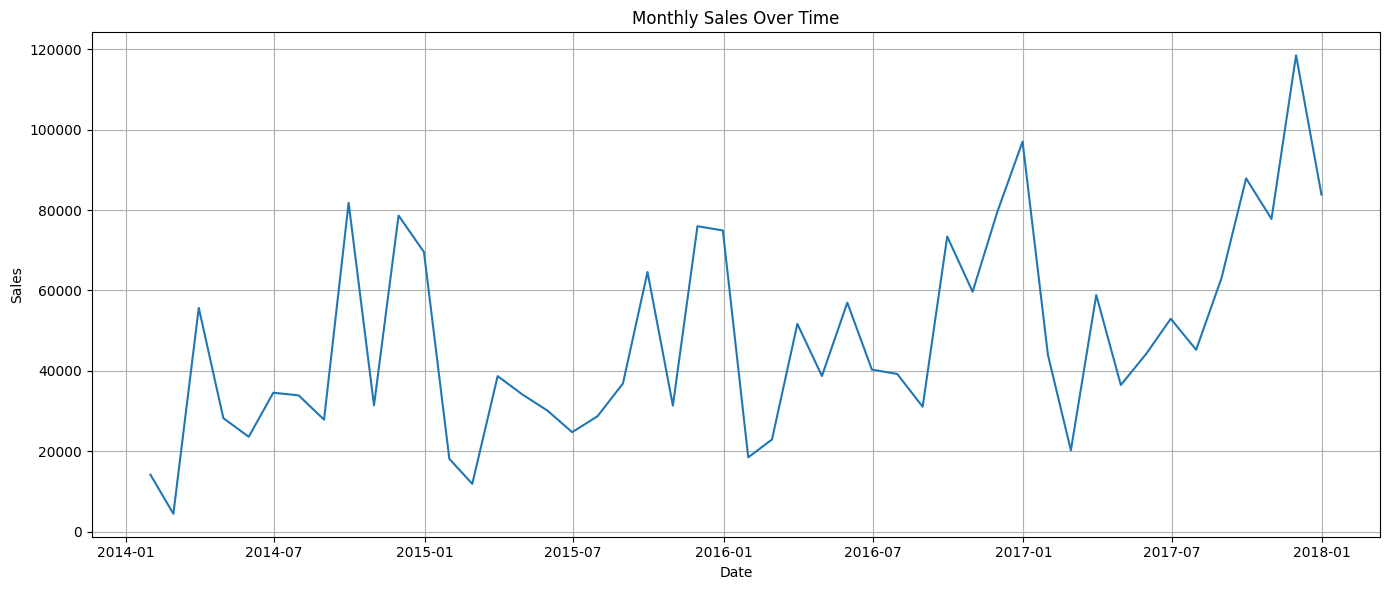

In [33]:
#historical sales

plt.figure(figsize=(14, 6))

plt.plot(monthly_sales)

plt.title("Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

plt.tight_layout()
plt.show()

In [34]:
sales_ts = monthly_sales.to_frame(name="Sales")

sales_ts.head()

,Sales
Order Date,
2014-01-31,14236.895
2014-02-28,4519.892
2014-03-31,55691.009
2014-04-30,28295.345
2014-05-31,23648.287


In [35]:
print(sales_ts.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2014-01-31 to 2017-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   48 non-null     float64
dtypes: float64(1)
memory usage: 768.0 bytes
None


In [36]:
print("Missing dates:", df["Order Date"].isna().sum())

Missing dates: 0


In [37]:
#analyze the trend

yearly_sales = df.groupby(
    df["Order Date"].dt.year
)["Sales"].sum()

print(yearly_sales)

Order Date
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


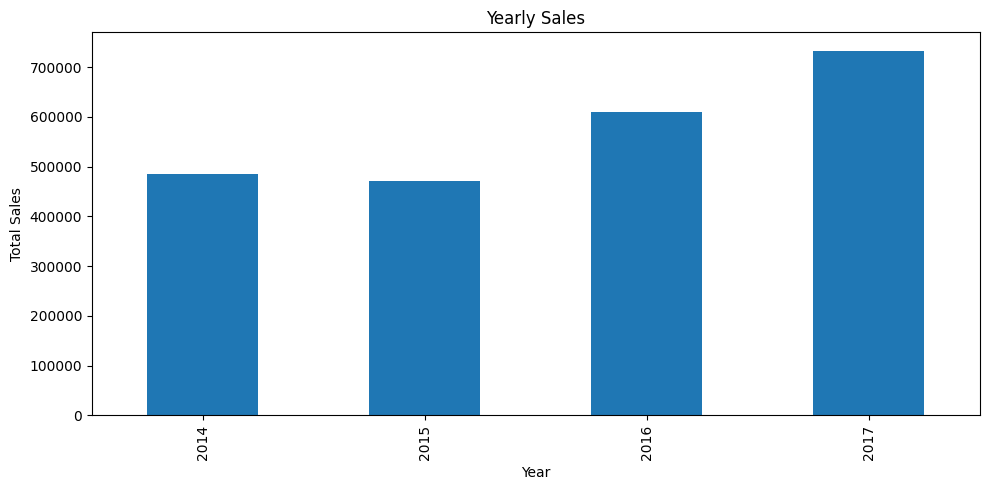

In [38]:
plt.figure(figsize=(10, 5))

yearly_sales.plot(kind="bar")

plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

#analyze seasonality

In [39]:
monthly_pattern = df.groupby(
    df["Order Date"].dt.month
)["Sales"].sum()

print(monthly_pattern)

Order Date
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


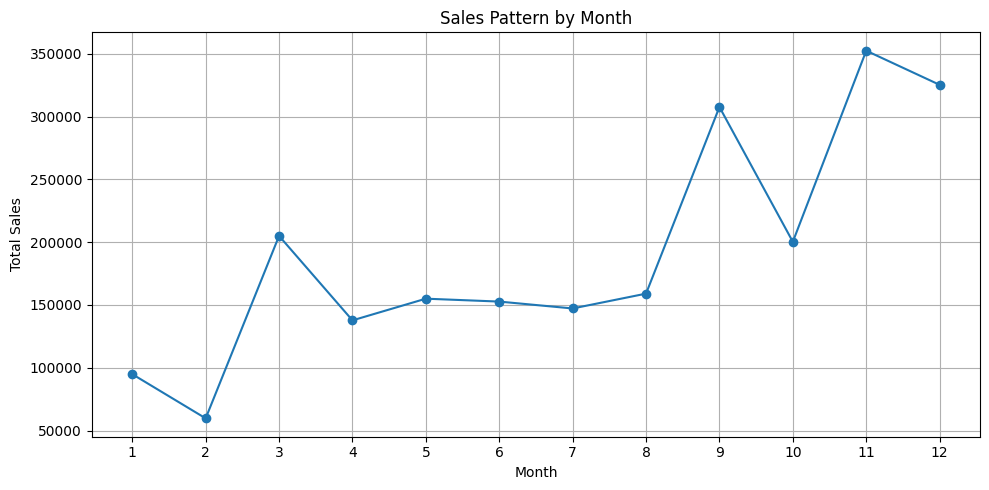

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_pattern.index,
    monthly_pattern.values,
    marker="o"
)

plt.title("Sales Pattern by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))

plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
train_size = int(len(sales_ts) * 0.8)

train = sales_ts.iloc[:train_size]
test = sales_ts.iloc[train_size:]

print("Training data:", train.shape)
print("Testing data:", test.shape)

Training data: (38, 1)
Testing data: (10, 1)


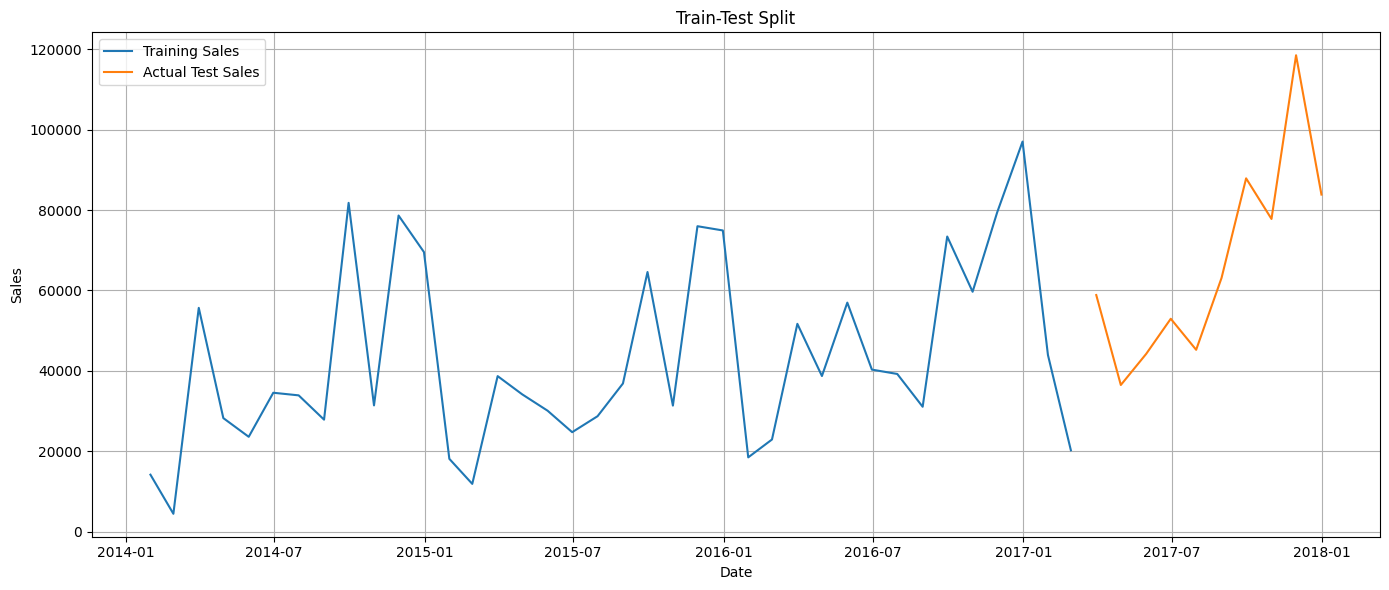

In [42]:
plt.figure(figsize=(14, 6))

plt.plot(train.index, train["Sales"], label="Training Sales")
plt.plot(test.index, test["Sales"], label="Actual Test Sales")

plt.title("Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [43]:
#import sarima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [44]:
#sarima model
model = SARIMAX(
    train["Sales"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   38
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -118.375
Date:                            Sat, 15 Aug 2026   AIC                            246.751
Time:                                    17:40:51   BIC                            248.740
Sample:                                01-31-2014   HQIC                           245.496
                                     - 02-28-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2526      0.621     -0.407      0.684      -1.469       0.964
ma.L1         -0.9875      1.008   

In [46]:
#generate predictions
forecast = model_fit.forecast(steps=len(test))

print(forecast)

2017-03-31     67255.726426
2017-04-30     50381.774397
2017-05-31     67496.490539
2017-06-30     51838.474868
2017-07-31     51313.341853
2017-08-31     44711.867375
2017-09-30     85685.210311
2017-10-31     69861.798041
2017-11-30     92126.463922
2017-12-31    107744.219706
Freq: ME, Name: predicted_mean, dtype: float64


In [49]:
#calculate evaluation metrics
mae = mean_absolute_error(test["Sales"], forecast)

rmse = np.sqrt(
    mean_squared_error(test["Sales"], forecast)
)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Mean Absolute Error (MAE): 13141.3
Root Mean Squared Error (RMSE): 15846.78


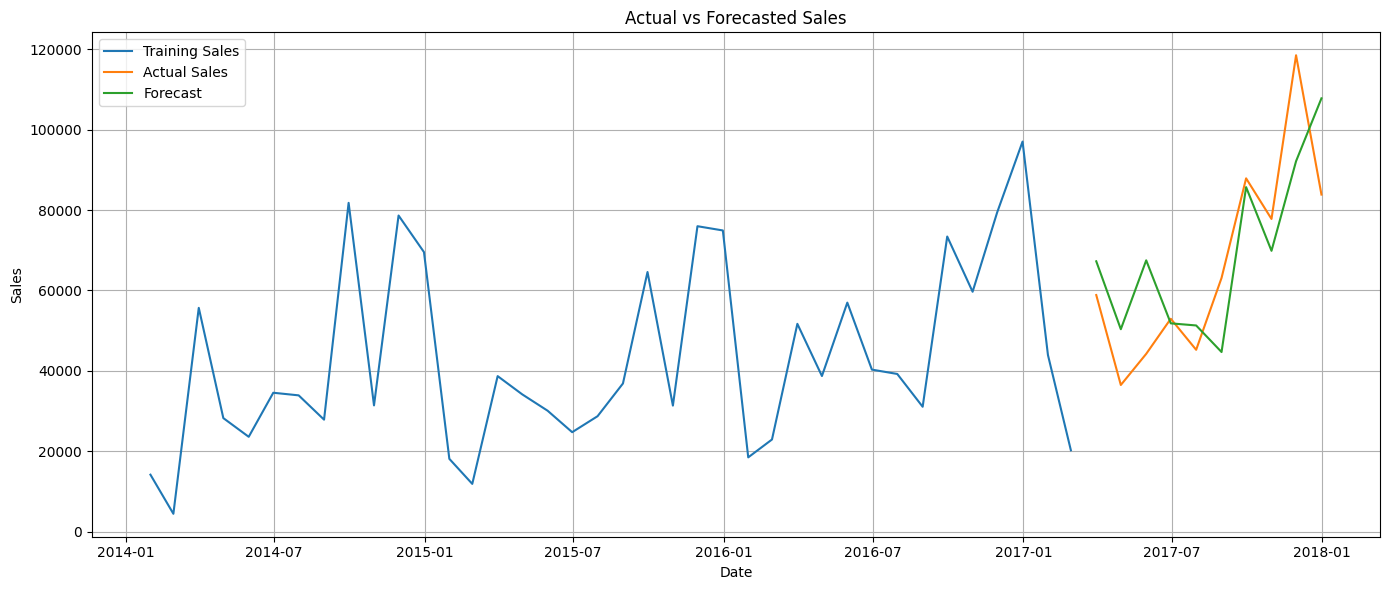

In [48]:
#actual vs forecast
plt.figure(figsize=(14, 6))

plt.plot(train.index, train["Sales"], label="Training Sales")
plt.plot(test.index, test["Sales"], label="Actual Sales")
plt.plot(test.index, forecast, label="Forecast")

plt.title("Actual vs Forecasted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [50]:
print("SALES FORECASTING PROJECT - FINAL RESULTS")
print("------------------------------------------")
print("Model: SARIMA")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

print("\nKey Insights:")
print("1. Sales generally increased from 2014 to 2017.")
print("2. Sales showed noticeable monthly seasonality.")
print("3. September and November showed relatively high sales.")
print("4. February showed relatively low sales.")
print("5. SARIMA captured the overall trend and seasonal pattern.")

SALES FORECASTING PROJECT - FINAL RESULTS
------------------------------------------
Model: SARIMA
MAE: 13141.30
RMSE: 15846.78

Key Insights:
1. Sales generally increased from 2014 to 2017.
2. Sales showed noticeable monthly seasonality.
3. September and November showed relatively high sales.
4. February showed relatively low sales.
5. SARIMA captured the overall trend and seasonal pattern.
